In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../'))

import numpy as np
import tensorflow as tf
import random

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

2026-05-14 14:52:33.557580: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778770353.582919    1754 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778770353.590739    1754 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778770353.609479    1754 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778770353.609506    1754 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778770353.609510    1754 computation_placer.cc:177] computation placer alr

In [2]:
import json
from src.pipeline.captioning_scratch import ImageCaptionerScratch
from src.evaluation.metrics import compute_bleu4, compute_meteor, timed_predict_from_features

VOCAB_PATH = '../../data/captions/vocab.json'
TEST_CAPTIONS_PATH = '../../data/captions/test_captions.json'
TEST_FEATURES_PATH = '../../data/features/test_features.npy'

with open(TEST_CAPTIONS_PATH) as f:
    test_data = json.load(f)

test_image_names = list(test_data.keys())
test_references  = [test_data[name] for name in test_image_names]

test_features = np.load(TEST_FEATURES_PATH, allow_pickle=True).item()
if isinstance(test_features, dict):
    test_feat_matrix = np.stack([test_features[n] for n in test_image_names])
else:
    test_feat_matrix = test_features

print(f'Test images: {len(test_image_names)}')
print(f'Feature matrix shape: {test_feat_matrix.shape}')

Test images: 1012
Feature matrix shape: (1012, 2048)


In [3]:
VARIANTS = {
    # RNN
    'rnn_1layer_128':  {'type': 'rnn',  'weights': '../../weights/rnn_lstm/rnn_preinject_L1_H128.h5'},
    'rnn_2layer_128':  {'type': 'rnn',  'weights': '../../weights/rnn_lstm/rnn_preinject_L2_H128.h5'},
    'rnn_3layer_128':  {'type': 'rnn',  'weights': '../../weights/rnn_lstm/rnn_preinject_L3_H128.h5'},
    'rnn_1layer_512':  {'type': 'rnn',  'weights': '../../weights/rnn_lstm/rnn_preinject_L1_H512.h5'},
    'rnn_2layer_512':  {'type': 'rnn',  'weights': '../../weights/rnn_lstm/rnn_preinject_L2_H512.h5'},
    'rnn_3layer_512':  {'type': 'rnn',  'weights': '../../weights/rnn_lstm/rnn_preinject_L3_H512.h5'},
    # LSTM
    'lstm_1layer_128': {'type': 'lstm', 'weights': '../../weights/rnn_lstm/lstm_preinject_L1_H128.h5'},
    'lstm_2layer_128': {'type': 'lstm', 'weights': '../../weights/rnn_lstm/lstm_preinject_L2_H128.h5'},
    'lstm_3layer_128': {'type': 'lstm', 'weights': '../../weights/rnn_lstm/lstm_preinject_L3_H128.h5'},
    'lstm_1layer_512': {'type': 'lstm', 'weights': '../../weights/rnn_lstm/lstm_preinject_L1_H512.h5'},
    'lstm_2layer_512': {'type': 'lstm', 'weights': '../../weights/rnn_lstm/lstm_preinject_L2_H512.h5'},
    'lstm_3layer_512': {'type': 'lstm', 'weights': '../../weights/rnn_lstm/lstm_preinject_L3_H512.h5'},
}

In [4]:
results = {}

for variant_name, config in VARIANTS.items():
    print(f'\n=== {variant_name} ===')
    captioner = ImageCaptionerScratch(decoder_type=config['type'])
    captioner.load_weights(
        cnn_encoder_path='InceptionV3',
        decoder_weights_path=config['weights'],
        vocab_path=VOCAB_PATH,
    )

    captions, total_time, avg_time = timed_predict_from_features(
        captioner, test_feat_matrix, max_len=20
    )
    bleu4  = compute_bleu4(test_references, captions)
    meteor = compute_meteor(test_references, captions)

    results[variant_name] = {
        'bleu4':             bleu4,
        'meteor':            meteor,
        'total_time':        total_time,
        'avg_time_per_image': avg_time,
        'captions':          captions,
    }
    print(f'  BLEU-4={bleu4:.4f}  METEOR={meteor:.4f}  avg={avg_time:.3f}s')


=== rnn_1layer_128 ===


I0000 00:00:1778770364.667992    1754 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5447 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778770364.673195    1754 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13655 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  BLEU-4=0.0023  METEOR=0.1592  avg=0.004s

=== rnn_2layer_128 ===


  BLEU-4=0.0024  METEOR=0.1678  avg=0.004s

=== rnn_3layer_128 ===


  BLEU-4=0.0018  METEOR=0.1539  avg=0.005s

=== rnn_1layer_512 ===


...

  BLEU-4=0.0009  METEOR=0.1416  avg=0.008s

=== lstm_3layer_128 ===


  BLEU-4=0.0010  METEOR=0.1570  avg=0.010s

=== lstm_1layer_512 ===


  BLEU-4=0.0026  METEOR=0.1592  avg=0.022s

=== lstm_2layer_512 ===


  BLEU-4=0.0022  METEOR=0.1416  avg=0.048s

=== lstm_3layer_512 ===


  BLEU-4=0.0028  METEOR=0.1487  avg=0.070s


In [5]:
import json, pandas as pd
import os

os.makedirs('../../results/tables', exist_ok=True)

# Save scores (without raw captions)
scores_only = {
    k: {kk: vv for kk, vv in v.items() if kk != 'captions'}
    for k, v in results.items()
}
with open('../../results/tables/all_variants_scores.json', 'w') as f:
    json.dump(scores_only, f, indent=2)

# Summary table
df = pd.DataFrame([
    {
        'variant':    k,
        'type':       'RNN' if 'rnn' in k else 'LSTM',
        'bleu4':      round(v['bleu4'], 4),
        'meteor':     round(v['meteor'], 4),
        'avg_time_s': round(v['avg_time_per_image'], 3),
    }
    for k, v in results.items()
]).sort_values('bleu4', ascending=False)

display(df)

,variant,type,bleu4,meteor,avg_time_s
4,rnn_2layer_512,RNN,0.0048,0.1480,0.018
11,lstm_3layer_512,LSTM,0.0028,0.1487,0.070
9,lstm_1layer_512,LSTM,0.0026,0.1592,0.022
1,rnn_2layer_128,RNN,0.0024,0.1678,0.004
0,rnn_1layer_128,RNN,0.0023,0.1592,0.004
3,rnn_1layer_512,RNN,0.0023,0.1531,0.012
10,lstm_2layer_512,LSTM,0.0022,0.1416,0.048
2,rnn_3layer_128,RNN,0.0018,0.1539,0.005
5,rnn_3layer_512,RNN,0.0017,0.1470,0.025
6,lstm_1layer_128,LSTM,0.0016,0.1479,0.005


/tmp/ipykernel_1754/2818491046.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(names, rotation=45, ha='right')
/tmp/ipykernel_1754/2818491046.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(names, rotation=45, ha='right')


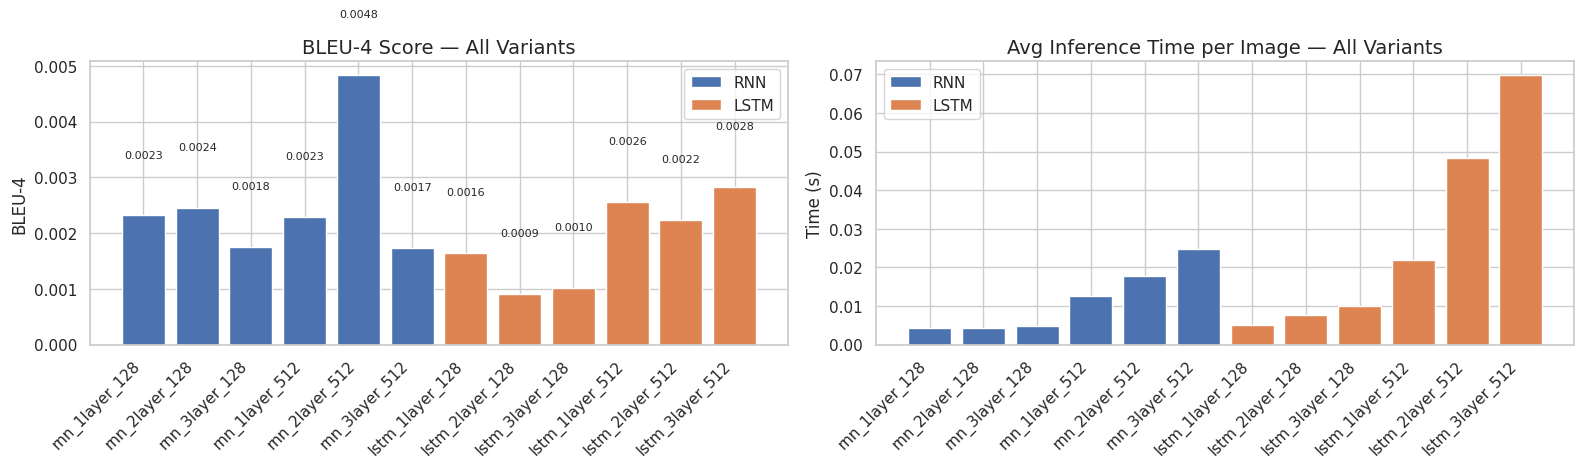

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('../../results/plots', exist_ok=True)

names  = list(results.keys())
bleu4s = [results[n]['bleu4'] for n in names]
times  = [results[n]['avg_time_per_image'] for n in names]
colors = ['#4C72B0' if 'rnn' in n else '#DD8452' for n in names]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# BLEU-4
bars = axes[0].bar(names, bleu4s, color=colors)
axes[0].set_title('BLEU-4 Score — All Variants', fontsize=14)
axes[0].set_ylabel('BLEU-4', fontsize=12)
axes[0].set_xticklabels(names, rotation=45, ha='right')
for bar, val in zip(bars, bleu4s):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# Avg time
bars2 = axes[1].bar(names, times, color=colors)
axes[1].set_title('Avg Inference Time per Image — All Variants', fontsize=14)
axes[1].set_ylabel('Time (s)', fontsize=12)
axes[1].set_xticklabels(names, rotation=45, ha='right')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', label='RNN'),
                   Patch(facecolor='#DD8452', label='LSTM')]
axes[0].legend(handles=legend_elements)
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('../../results/plots/bleu4_and_time_all_variants.png', dpi=150, bbox_inches='tight')
plt.show()